In [1]:
import polars as pl #библиотека для работы с датафреймами
import pandas as pd #библиотека для работы с датафреймами
import time #библиотека для работы со временем 

In [2]:
pip install polars pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\gruni\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
print("⏱️  Читаем через Pandas...")
start = time.time()
df_pandas = pd.read_excel("ШЧ_2_corr.xlsx")
pandas_time = time.time() - start
print(pandas_time)

⏱️  Читаем через Pandas...
4.390765428543091


In [4]:
print("⏱️  Читаем через Pandas...")
start = time.time()
df = pl.read_excel('ШЧ_2_corr.xlsx')
popars_time = time.time() - start
print(popars_time)

⏱️  Читаем через Pandas...


Could not determine dtype for column 10, falling back to string


0.38300609588623047


C:\Users\gruni\AppData\Local\Temp\ipykernel_14032\1746993790.py:3: FutureWarning: from_arrow(<ArrowStreamExportable>) will return a Series instead of a DataFrame in 2.0. To avoid this warning, pass the ArrowStreamExportable to either `pl.DataFrame` or `pl.Series` instead based on your desired output type.
  df = pl.read_excel('ШЧ_2_corr.xlsx')


In [5]:
# Посмотрим наши данные.
df.head()

__UNNAMED__0,Дата осмотра,Осмотр проводил,"Станция, перегон","Объекты, количество отступлений",Классификация (Группа),Классификация (Вид),Примечание,Крайний срок,Статус,Причина,Дата устранения
i64,date,str,str,str,str,str,str,date,str,str,date
0,2019-04-03,"""Сотрудник_0""","""станция_0""","""327""","""группа_0""","""вид_0""","""Стрелка №39 устранить люфт дли…",2019-04-13,"""ЗАКРЫТО""",null,2019-04-11
1,2019-04-03,"""Сотрудник_0""","""станция_0""","""327""","""группа_0""","""вид_0""","""Стрелка №25 отрегулировать раб…",2019-04-13,"""ЗАКРЫТО""",null,2019-04-11
2,2019-04-03,"""Сотрудник_0""","""станция_0""","""327""","""группа_0""","""вид_0""","""Стрелка №31 устранить люфт дли…",2019-04-13,"""ЗАКРЫТО""",null,2019-04-11
3,2019-04-03,"""Сотрудник_0""","""станция_0""","""327""","""группа_0""","""вид_0""","""Стрелка №35 закрепить фартук н…",2019-04-13,"""ЗАКРЫТО""",null,2019-04-11
4,2019-04-03,"""Сотрудник_0""","""станция_0""","""327""","""группа_0""","""вид_0""","""На стрелке №327 устранить люфт…",2019-04-15,"""ЗАКРЫТО""",null,2019-04-13


# Исследуем энтропию данных
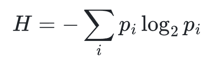

In [6]:
# Для расчета энетропии нам нужны библиотеки, способные работать с формулами
import math
# Определим сколько у нас нарушений
total = len(df)
print('Всего нарушений:', total)

Всего нарушений: 12112


In [7]:
# Формула Шеннона
entropy_total = math.log2(total)
print('Общая энтропия', entropy_total)
# Задание № 1 - определить почему формула math.log2(total) не похожа на формулу Шеннона выше.

Общая энтропия 13.564149489985732


In [8]:
# Проведем анализ частоты события
df["Классификация (Вид)"].value_counts()

Классификация (Вид),count
str,u32
"""вид_26""",13
"""вид_71""",7
"""вид_24""",22
"""вид_89""",22
"""вид_136""",5
…,…
"""вид_168""",1
"""вид_109""",11
"""вид_181""",2


In [9]:
# Проведем анализ частоты события + сортировка по частоте
df["Классификация (Вид)"].value_counts().sort(by = ['count'])

Классификация (Вид),count
str,u32
"""вид_170""",1
"""вид_106""",1
"""вид_14""",1
"""вид_22""",1
"""вид_166""",1
…,…
"""вид_0""",1059
"""вид_2""",1424
"""вид_4""",1655


In [10]:
# Посмотрим общее количество событий
df["Классификация (Вид)"].value_counts()['count'].sum()

12112

In [11]:
# Расчет частот (вероятностей)
for i in df["Классификация (Вид)"].value_counts()['count']:
    print(i/df["Классификация (Вид)"].value_counts()['count'].sum())

0.0014035667107001322
0.0015686922060766182
8.256274768824307e-05
0.0017338177014531043
0.0009081902245706737
8.256274768824307e-05
0.0009081902245706737
0.0006605019815059445
0.00033025099075297226
0.0005779392338177015
8.256274768824307e-05
0.00016512549537648613
0.0006605019815059445
8.256274768824307e-05
0.0002476882430647292
0.009577278731836196
0.00016512549537648613
0.00033025099075297226
0.0005779392338177015
8.256274768824307e-05
0.001155878467635403
0.0002476882430647292
0.11756935270805813
8.256274768824307e-05
8.256274768824307e-05
0.0002476882430647292
0.00016512549537648613
0.0004953764861294584
0.0007430647291941875
0.00041281373844121534
0.0005779392338177015
0.0017338177014531043
8.256274768824307e-05
8.256274768824307e-05
0.0005779392338177015
0.002311756935270806
0.0232001321003963
0.003632760898282695
8.256274768824307e-05
8.256274768824307e-05
0.002064068692206077
8.256274768824307e-05
8.256274768824307e-05
0.0005779392338177015
0.0005779392338177015
0.000577939233

In [18]:
# Формула Шеннона
entropy_raw = -sum((c/total) * math.log2(c/total) for c in counts_raw if c > 0)

# Задание № 1 внесите правки в код сделайте так, чтобы расчет entropy_raw работал, а ошибок:
- NameError: name 'counts_raw' is not defined
- NameError: name 'total' is not defined
# не появлялось

In [17]:
counts_raw = df["Классификация (Вид)"].value_counts()['count']

# Задание № 2
- entropy_total - максимально возможная энетропия в наших данных
- рассчитайте entropy_type - расчитайте энетропию с учетом вида нарушений
- рассчитайте entropy_class - расчитайте энетропию с учетом класса нарушений
- сравните полученные значений, определите, что является информаций

# Вспомогательное:
print(f"\n Энтропия общая: H = {entropy_total:.3f} бит") \
print(f"🎯 Энтропия по виду нарушения: H = {entropy_type:.3f} бит") \
print(f"📉 Неопределенность снизилась на {entropy_total - entropy_type:.3f} бит " \
      f"({(1 - entropy_info/entropy_total)*100:.1f}%)") 


In [21]:
total = len(df)
entropy_total = math.log2(total)

counts_type = df["Классификация (Вид)"].value_counts()['count']
entropy_type = -sum((c/total) * math.log2(c/total) for c in counts_type if c > 0)

counts_group = df["Классификация (Группа)"].value_counts()['count']
entropy_group = -sum((c/total) * math.log2(c/total) for c in counts_group if c > 0)

entropy_info_type = entropy_total - entropy_type
entropy_info_group = entropy_total - entropy_group

In [23]:
print(f"Энтропия общая: H = {entropy_total:.3f} бит")
print(f"Энтропия по виду нарушения: H = {entropy_type:.3f} бит")
print(f"Энтропия по классу нарушения: H = {entropy_group:.3f} бит")
print(f"Неопределённость (по виду) снизилась на {entropy_total - entropy_type} бит "
      f"({(1 - entropy_info_type/entropy_total) * 100:.1f}%)")
print(f"Неопределённость (по классу) снизилась на {entropy_total - entropy_group} бит "
      f"({(1 - entropy_info_group/entropy_total) * 100:.1f}%)")

Энтропия общая: H = 13.564 бит
Энтропия по виду нарушения: H = 3.806 бит
Энтропия по классу нарушения: H = 3.561 бит
Неопределённость (по виду) снизилась на 9.758386379270092 бит (28.1%)
Неопределённость (по классу) снизилась на 10.00266736850735 бит (26.3%)
